In [1]:

# ============================================
# 05 - HYPERPARAMETER TUNING
# ============================================

# Standard libraries
import time
from pathlib import Path

# Numerical processing
import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Pretrained models
from torchvision import models

# Progress bar
from tqdm.auto import tqdm

# Evaluation metrics
from sklearn.metrics import f1_score


# ============================================
# REPRODUCIBILITY
# ============================================

# Set a fixed seed so tuning experiments are
# as reproducible as possible.
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)


# ============================================
# DEVICE
# ============================================

# Automatically use the NVIDIA GPU when CUDA
# is available.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================
# BASIC CONFIGURATION
# ============================================

# Number of disease classes
NUM_CLASSES = 6

# Input image size
IMAGE_SIZE = 224

# Batch size selected for the GTX 1650
BATCH_SIZE = 16

# Maximum epochs for each tuning experiment.
# We keep this smaller than a full training run
# because we will test multiple configurations.
TUNING_EPOCHS = 8

# Early stopping patience for each experiment
TUNING_PATIENCE = 2


# ============================================
# DISPLAY CONFIGURATION
# ============================================

print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Number of classes:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)
print("Tuning epochs:", TUNING_EPOCHS)
print("Tuning patience:", TUNING_PATIENCE)

PyTorch version: 2.9.1+cu126
Device: cuda
Number of classes: 6
Batch size: 16
Tuning epochs: 8
Tuning patience: 2


In [2]:
# ============================================
# LOAD DATA FOR HYPERPARAMETER TUNING
# ============================================

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# ============================================
# DATASET PATHS
# ============================================

# Root folder containing our cleaned classification images.
DATASET_PATH = Path(
    r"D:\AI_Diploma\Training tasks\Sprint_2\dataset"
)

# Folder containing the fixed train/validation/test CSV files.
SPLIT_PATH = Path("data_splits")


# ============================================
# CLASS CONFIGURATION
# ============================================

# Keep exactly the same class order used by all
# previous experiments.
class_names = [
    "Calculus",
    "Caries",
    "Gingivitis",
    "Hypodontia",
    "Mouth Ulcer",
    "Tooth Discoloration"
]

# Convert class name → numerical class index.
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

# Convert numerical index → class name.
idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}


# ============================================
# LOAD FIXED DATA SPLITS
# ============================================

# These are the exact same splits used for
# ResNet18, EfficientNet-B0, and MobileNetV3.
train_df = pd.read_csv(
    SPLIT_PATH / "train.csv"
)

val_df = pd.read_csv(
    SPLIT_PATH / "validation.csv"
)

test_df = pd.read_csv(
    SPLIT_PATH / "test.csv"
)


# ============================================
# IMAGE TRANSFORMS
# ============================================

# ImageNet statistics are used because our
# pretrained EfficientNet was trained with them.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Training transformation.
# Random augmentation is used only for training.
train_transform = transforms.Compose([
    # Resize every image to 224 × 224.
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Randomly mirror the image horizontally.
    transforms.RandomHorizontalFlip(p=0.5),

    # Simulate small camera-angle differences.
    transforms.RandomRotation(degrees=15),

    # Simulate small changes in position and scale.
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    # Simulate mild differences in lighting.
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    # Convert PIL image → PyTorch tensor.
    transforms.ToTensor(),

    # Normalize using ImageNet statistics.
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# Validation/test transformation.
# No random augmentation is applied here.
val_test_transform = transforms.Compose([
    # Resize to the same model input size.
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Convert image to tensor.
    transforms.ToTensor(),

    # Apply the same normalization.
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ============================================
# DATASET CLASS
# ============================================

class OralDiseaseDataset(Dataset):

    def __init__(self, dataframe, dataset_path, transform=None):
        # Reset the DataFrame index for consistent indexing.
        self.dataframe = dataframe.reset_index(drop=True)

        # Store the root dataset directory.
        self.dataset_path = Path(dataset_path)

        # Store the preprocessing/augmentation pipeline.
        self.transform = transform

    def __len__(self):
        # Return the number of images.
        return len(self.dataframe)

    def __getitem__(self, index):
        # Get information about the selected image.
        row = self.dataframe.iloc[index]

        # Build the complete image path.
        image_path = self.dataset_path / row["relative_path"]

        # Open the image and convert it to RGB.
        image = Image.open(image_path).convert("RGB")

        # Convert the class name to its integer label.
        label = class_to_idx[row["class"]]

        # Apply the appropriate transform.
        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================
# CREATE DATASETS
# ============================================

train_dataset = OralDiseaseDataset(
    dataframe=train_df,
    dataset_path=DATASET_PATH,
    transform=train_transform
)

val_dataset = OralDiseaseDataset(
    dataframe=val_df,
    dataset_path=DATASET_PATH,
    transform=val_test_transform
)

test_dataset = OralDiseaseDataset(
    dataframe=test_df,
    dataset_path=DATASET_PATH,
    transform=val_test_transform
)


# ============================================
# CREATE DATALOADERS
# ============================================

# Batch size remains 16 because it worked reliably
# on our GTX 1650 with 4 GB VRAM.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# ============================================
# CLASS WEIGHTS
# ============================================

# Use the same weights calculated from the
# training set during the EDA phase.
class_weights = torch.tensor(
    [
        3.8132,  # Calculus
        0.6648,  # Caries
        1.3842,  # Gingivitis
        1.4086,  # Hypodontia
        0.6143,  # Mouth Ulcer
        0.8522   # Tooth Discoloration
    ],
    dtype=torch.float32
).to(device)


# ============================================
# VERIFY DATA
# ============================================

print("Data loaded successfully.")
print("--------------------------------")
print("Training images   :", len(train_dataset))
print("Validation images :", len(val_dataset))
print("Test images       :", len(test_dataset))
print("Batch size        :", BATCH_SIZE)

print("\nClass weights:")
for idx, class_name in enumerate(class_names):
    print(
        f"{class_name:20s}: "
        f"{class_weights[idx].item():.4f}"
    )

Data loaded successfully.
--------------------------------
Training images   : 7184
Validation images : 1540
Test images       : 1540
Batch size        : 16

Class weights:
Calculus            : 3.8132
Caries              : 0.6648
Gingivitis          : 1.3842
Hypodontia          : 1.4086
Mouth Ulcer         : 0.6143
Tooth Discoloration : 0.8522


In [3]:
# ============================================
# EFFICIENTNET-B0 MODEL BUILDER
# ============================================

def create_efficientnet():
    """
    Create a fresh EfficientNet-B0 using ImageNet
    pretrained weights and replace its final layer
    with our six oral-disease classes.
    """

    # Load a completely fresh EfficientNet-B0.
    # DEFAULT loads the pretrained ImageNet weights.
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.DEFAULT
    )

    # Get the number of input features going into
    # the original ImageNet classification layer.
    num_features = model.classifier[-1].in_features

    # Replace the original 1000-class ImageNet layer
    # with our 6-class oral disease classifier.
    model.classifier[-1] = nn.Linear(
        num_features,
        NUM_CLASSES
    )

    # Move the model to our NVIDIA GPU.
    model = model.to(device)

    return model


# ============================================
# TEST THE MODEL BUILDER
# ============================================

# Create one fresh model to verify that the
# function works correctly.
test_model = create_efficientnet()

print("Fresh EfficientNet-B0 created successfully.")
print("Classifier:")
print(test_model.classifier[-1])
print("Device:", next(test_model.parameters()).device)

Fresh EfficientNet-B0 created successfully.
Classifier:
Linear(in_features=1280, out_features=6, bias=True)
Device: cuda:0


In [4]:
# ============================================
# SINGLE HYPERPARAMETER EXPERIMENT
# ============================================

from copy import deepcopy


def tune_learning_rate(
    learning_rate,
    epochs=TUNING_EPOCHS,
    patience=TUNING_PATIENCE
):
    """
    Train a fresh EfficientNet-B0 using one learning
    rate and return its best validation performance.

    Parameters
    ----------
    learning_rate : float
        Learning rate to test.

    epochs : int
        Maximum number of training epochs.

    patience : int
        Number of epochs allowed without improvement.

    Returns
    -------
    result : dict
        Best validation metrics and the tested
        learning rate.
    """

    # ========================================
    # CREATE A FRESH MODEL
    # ========================================

    # Every experiment starts from the same
    # ImageNet-pretrained EfficientNet-B0.
    model = create_efficientnet()


    # ========================================
    # LOSS FUNCTION
    # ========================================

    # Use the same class-weighted loss as before
    # so the tuning experiment remains consistent.
    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )


    # ========================================
    # OPTIMIZER
    # ========================================

    # Create a new optimizer for this fresh model.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.0001
    )


    # ========================================
    # MIXED PRECISION
    # ========================================

    # Use mixed precision when CUDA is available.
    use_amp = device.type == "cuda"

    # Create a separate gradient scaler for
    # this experiment.
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp
    )


    # ========================================
    # EXPERIMENT VARIABLES
    # ========================================

    # Best validation loss seen during this run.
    best_val_loss = float("inf")

    # Best Macro F1 seen during this run.
    best_macro_f1 = 0.0

    # Store best validation accuracy.
    best_val_accuracy = 0.0

    # Count epochs without validation improvement.
    epochs_without_improvement = 0


    # ========================================
    # TRAINING LOOP
    # ========================================

    for epoch in range(1, epochs + 1):

        # ----------------------------
        # TRAINING
        # ----------------------------

        model.train()

        train_correct = 0
        train_total = 0

        # Training progress bar.
        progress_bar = tqdm(
            train_loader,
            desc=f"LR {learning_rate:.0e} | "
                 f"Epoch {epoch}/{epochs}",
            unit="batch",
            colour="green",
            leave=False
        )

        for images, labels in progress_bar:

            # Move data to the GPU.
            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients.
            optimizer.zero_grad(
                set_to_none=True
            )

            # Mixed-precision forward pass.
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp
            ):

                # Generate predictions.
                outputs = model(images)

                # Calculate weighted loss.
                loss = criterion(
                    outputs,
                    labels
                )

            # Backpropagation.
            scaler.scale(loss).backward()

            # Update model parameters.
            scaler.step(optimizer)

            # Update gradient scaler.
            scaler.update()

            # Calculate predictions for tracking accuracy.
            _, predictions = torch.max(
                outputs,
                1
            )

            train_total += labels.size(0)

            train_correct += (
                predictions == labels
            ).sum().item()

            # Update progress bar.
            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )


        # Calculate training accuracy.
        train_accuracy = (
            train_correct / train_total
        )


        # ----------------------------
        # VALIDATION
        # ----------------------------

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        validation_predictions = []
        validation_labels = []

        # Disable gradients during validation.
        with torch.no_grad():

            for images, labels in val_loader:

                # Move data to GPU.
                images = images.to(device)
                labels = labels.to(device)

                # Forward pass.
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=use_amp
                ):

                    outputs = model(images)

                    # Calculate validation loss.
                    loss = criterion(
                        outputs,
                        labels
                    )

                # Accumulate loss.
                val_running_loss += (
                    loss.item() *
                    images.size(0)
                )

                # Get predictions.
                _, predictions = torch.max(
                    outputs,
                    1
                )

                # Update accuracy counters.
                val_total += labels.size(0)

                val_correct += (
                    predictions == labels
                ).sum().item()

                # Store predictions for Macro F1.
                validation_predictions.extend(
                    predictions.cpu().numpy()
                )

                validation_labels.extend(
                    labels.cpu().numpy()
                )


        # Calculate average validation loss.
        val_loss = (
            val_running_loss / val_total
        )

        # Calculate validation accuracy.
        val_accuracy = (
            val_correct / val_total
        )

        # Calculate Macro F1.
        val_macro_f1 = f1_score(
            validation_labels,
            validation_predictions,
            average="macro"
        )


        # ----------------------------
        # DISPLAY EPOCH RESULT
        # ----------------------------

        print(
            f"LR={learning_rate:.0e} | "
            f"Epoch {epoch}/{epochs} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f}"
        )


        # ----------------------------
        # CHECK IMPROVEMENT
        # ----------------------------

        if val_loss < best_val_loss:

            # Store the new best validation loss.
            best_val_loss = val_loss

            # Store corresponding Macro F1.
            best_macro_f1 = val_macro_f1

            # Store corresponding accuracy.
            best_val_accuracy = val_accuracy

            # Reset early stopping counter.
            epochs_without_improvement = 0

        else:

            # Validation loss did not improve.
            epochs_without_improvement += 1

        # ----------------------------
        # EARLY STOPPING
        # ----------------------------

        if epochs_without_improvement >= patience:

            print(
                f"Early stopping for LR "
                f"{learning_rate:.0e}"
            )

            break


    # ========================================
    # RETURN EXPERIMENT RESULT
    # ========================================

    return {
        "learning_rate": learning_rate,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "best_val_macro_f1": best_macro_f1
    }


print("Learning-rate tuning function created successfully.")

Learning-rate tuning function created successfully.


In [5]:
# ============================================
# RUN LEARNING-RATE EXPERIMENTS
# ============================================

# Learning rates we want to compare.
# The current baseline is 0.0001.
learning_rates = [
    0.00001,
    0.00005,
    0.00010,
    0.00030
]

# Store the results from every experiment.
tuning_results = []


# ============================================
# RUN EACH EXPERIMENT
# ============================================

for learning_rate in learning_rates:

    print("\n" + "=" * 70)
    print(
        f"STARTING EXPERIMENT: "
        f"Learning Rate = {learning_rate}"
    )
    print("=" * 70)

    # Train a completely fresh EfficientNet-B0
    # using the current learning rate.
    result = tune_learning_rate(
        learning_rate=learning_rate
    )

    # Save the experiment result.
    tuning_results.append(result)


# ============================================
# CREATE RESULTS TABLE
# ============================================

# Convert all experiment results into a DataFrame
# so we can easily compare the configurations.
tuning_results_df = pd.DataFrame(
    tuning_results
)

# Sort experiments by validation Macro F1,
# because this is our primary tuning metric.
tuning_results_df = tuning_results_df.sort_values(
    by="best_val_macro_f1",
    ascending=False
).reset_index(drop=True)


# ============================================
# DISPLAY RESULTS
# ============================================

print("\n" + "=" * 70)
print("LEARNING-RATE TUNING RESULTS")
print("=" * 70)

print(tuning_results_df)


STARTING EXPERIMENT: Learning Rate = 1e-05


LR 1e-05 | Epoch 1/8:   0%|          | 0/449 [00:00<?, ?batch/s]

LR=1e-05 | Epoch 1/8 | Train Acc: 0.4020 | Val Loss: 1.4258 | Val Acc: 0.6403 | Val Macro F1: 0.6030


LR 1e-05 | Epoch 2/8:   0%|          | 0/449 [00:00<?, ?batch/s]

LR=1e-05 | Epoch 2/8 | Train Acc: 0.6673 | Val Loss: 0.9381 | Val Acc: 0.7799 | Val Macro F1: 0.7348


...

LR=3e-04 | Epoch 6/8 | Train Acc: 0.9724 | Val Loss: 0.0660 | Val Acc: 0.9870 | Val Macro F1: 0.9818


LR 3e-04 | Epoch 7/8:   0%|          | 0/449 [00:00<?, ?batch/s]

LR=3e-04 | Epoch 7/8 | Train Acc: 0.9777 | Val Loss: 0.0307 | Val Acc: 0.9922 | Val Macro F1: 0.9879


LR 3e-04 | Epoch 8/8:   0%|          | 0/449 [00:00<?, ?batch/s]

LR=3e-04 | Epoch 8/8 | Train Acc: 0.9801 | Val Loss: 0.0418 | Val Acc: 0.9838 | Val Macro F1: 0.9768

LEARNING-RATE TUNING RESULTS
   learning_rate  best_val_loss  best_val_accuracy  best_val_macro_f1
0        0.00010       0.026364           0.994156           0.992788
1        0.00030       0.030722           0.992208           0.987907
2        0.00005       0.044837           0.987013           0.985208
3        0.00001       0.201653           0.937662           0.928256


In [6]:
# ============================================
# WEIGHT-DECAY HYPERPARAMETER EXPERIMENT
# ============================================

def tune_weight_decay(
    weight_decay,
    learning_rate=0.0001,
    epochs=TUNING_EPOCHS,
    patience=TUNING_PATIENCE
):
    """
    Train a fresh EfficientNet-B0 with one weight-decay
    value while keeping the learning rate fixed.

    Parameters
    ----------
    weight_decay : float
        Weight decay value to test.

    learning_rate : float
        Fixed learning rate selected from the previous
        tuning experiment.

    epochs : int
        Maximum number of epochs.

    patience : int
        Number of epochs allowed without improvement.

    Returns
    -------
    dict
        Best validation metrics from the experiment.
    """

    # ========================================
    # CREATE A FRESH MODEL
    # ========================================

    # Start every experiment from the exact same
    # ImageNet-pretrained EfficientNet-B0.
    model = create_efficientnet()


    # ========================================
    # LOSS FUNCTION
    # ========================================

    # Keep the same class-weighted loss used
    # throughout the project.
    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )


    # ========================================
    # OPTIMIZER
    # ========================================

    # Keep the winning learning rate fixed.
    # Only weight decay changes between experiments.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )


    # ========================================
    # MIXED PRECISION
    # ========================================

    # Enable mixed precision when using CUDA.
    use_amp = device.type == "cuda"

    # Create a fresh gradient scaler.
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp
    )


    # ========================================
    # TRACK BEST RESULTS
    # ========================================

    best_val_loss = float("inf")
    best_val_accuracy = 0.0
    best_macro_f1 = 0.0

    # Count consecutive epochs without improvement.
    epochs_without_improvement = 0


    # ========================================
    # TRAINING LOOP
    # ========================================

    for epoch in range(1, epochs + 1):

        # ----------------------------
        # TRAINING
        # ----------------------------

        model.train()

        train_correct = 0
        train_total = 0

        # Green progress bar for training batches.
        progress_bar = tqdm(
            train_loader,
            desc=(
                f"WD {weight_decay:.0e} | "
                f"Epoch {epoch}/{epochs}"
            ),
            unit="batch",
            colour="green",
            leave=False
        )

        for images, labels in progress_bar:

            # Move the batch to the GPU.
            images = images.to(device)
            labels = labels.to(device)

            # Clear gradients from the previous batch.
            optimizer.zero_grad(
                set_to_none=True
            )

            # Mixed-precision forward pass.
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp
            ):

                # Generate predictions.
                outputs = model(images)

                # Calculate class-weighted loss.
                loss = criterion(
                    outputs,
                    labels
                )

            # Backpropagation.
            scaler.scale(loss).backward()

            # Update model parameters.
            scaler.step(optimizer)

            # Update gradient scaler.
            scaler.update()

            # Track training accuracy.
            _, predictions = torch.max(
                outputs,
                1
            )

            train_total += labels.size(0)

            train_correct += (
                predictions == labels
            ).sum().item()

            # Show current loss on the progress bar.
            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )


        # Calculate training accuracy.
        train_accuracy = (
            train_correct / train_total
        )


        # ----------------------------
        # VALIDATION
        # ----------------------------

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        validation_predictions = []
        validation_labels = []

        # Disable gradients during validation.
        with torch.no_grad():

            for images, labels in val_loader:

                # Move validation data to the GPU.
                images = images.to(device)
                labels = labels.to(device)

                # Forward pass.
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=use_amp
                ):

                    outputs = model(images)

                    # Calculate validation loss.
                    loss = criterion(
                        outputs,
                        labels
                    )

                # Accumulate validation loss.
                val_running_loss += (
                    loss.item() *
                    images.size(0)
                )

                # Get predicted class.
                _, predictions = torch.max(
                    outputs,
                    1
                )

                # Track validation accuracy.
                val_total += labels.size(0)

                val_correct += (
                    predictions == labels
                ).sum().item()

                # Store predictions and true labels
                # for Macro F1 calculation.
                validation_predictions.extend(
                    predictions.cpu().numpy()
                )

                validation_labels.extend(
                    labels.cpu().numpy()
                )


        # Calculate validation metrics.
        val_loss = (
            val_running_loss / val_total
        )

        val_accuracy = (
            val_correct / val_total
        )

        val_macro_f1 = f1_score(
            validation_labels,
            validation_predictions,
            average="macro"
        )


        # ----------------------------
        # DISPLAY RESULTS
        # ----------------------------

        print(
            f"WD={weight_decay:.0e} | "
            f"Epoch {epoch}/{epochs} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f}"
        )


        # ----------------------------
        # CHECK IMPROVEMENT
        # ----------------------------

        if val_loss < best_val_loss:

            # Store the new best validation loss.
            best_val_loss = val_loss

            # Store the corresponding accuracy.
            best_val_accuracy = val_accuracy

            # Store the corresponding Macro F1.
            best_macro_f1 = val_macro_f1

            # Reset early-stopping counter.
            epochs_without_improvement = 0

        else:

            # Validation loss did not improve.
            epochs_without_improvement += 1


        # ----------------------------
        # EARLY STOPPING
        # ----------------------------

        if epochs_without_improvement >= patience:

            print(
                f"Early stopping for weight decay "
                f"{weight_decay:.0e}"
            )

            break


    # ========================================
    # RETURN RESULTS
    # ========================================

    return {
        "weight_decay": weight_decay,
        "learning_rate": learning_rate,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "best_val_macro_f1": best_macro_f1
    }


print("Weight-decay tuning function created successfully.")

Weight-decay tuning function created successfully.


In [7]:
# ============================================
# RUN WEIGHT-DECAY EXPERIMENTS
# ============================================

# Keep the best learning rate from the previous
# experiment fixed at 0.0001.
best_learning_rate = 0.0001

# Weight-decay values to compare.
weight_decay_values = [
    0.0,
    0.00001,
    0.0001,
    0.001
]

# Store results from all experiments.
weight_decay_results = []


# Run every configuration from a fresh model.
for weight_decay in weight_decay_values:

    print("\n" + "=" * 70)
    print(
        f"STARTING EXPERIMENT: "
        f"Weight Decay = {weight_decay}"
    )
    print("=" * 70)

    result = tune_weight_decay(
        weight_decay=weight_decay,
        learning_rate=best_learning_rate
    )

    weight_decay_results.append(result)


# Convert results to a DataFrame.
weight_decay_results_df = pd.DataFrame(
    weight_decay_results
)

# Rank configurations by validation Macro F1.
weight_decay_results_df = (
    weight_decay_results_df
    .sort_values(
        by="best_val_macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)


# Display the final comparison.
print("\n" + "=" * 70)
print("WEIGHT-DECAY TUNING RESULTS")
print("=" * 70)

print(weight_decay_results_df)


STARTING EXPERIMENT: Weight Decay = 0.0


WD 0e+00 | Epoch 1/8:   0%|          | 0/449 [00:00<?, ?batch/s]

WD=0e+00 | Epoch 1/8 | Train Acc: 0.7635 | Val Loss: 0.1968 | Val Acc: 0.9409 | Val Macro F1: 0.9310


WD 0e+00 | Epoch 2/8:   0%|          | 0/449 [00:00<?, ?batch/s]

WD=0e+00 | Epoch 2/8 | Train Acc: 0.9170 | Val Loss: 0.0906 | Val Acc: 0.9786 | Val Macro F1: 0.9712


...

WD=1e-03 | Epoch 4/8 | Train Acc: 0.9646 | Val Loss: 0.0273 | Val Acc: 0.9948 | Val Macro F1: 0.9949


WD 1e-03 | Epoch 5/8:   0%|          | 0/449 [00:00<?, ?batch/s]

WD=1e-03 | Epoch 5/8 | Train Acc: 0.9755 | Val Loss: 0.0460 | Val Acc: 0.9877 | Val Macro F1: 0.9840


WD 1e-03 | Epoch 6/8:   0%|          | 0/449 [00:00<?, ?batch/s]

WD=1e-03 | Epoch 6/8 | Train Acc: 0.9768 | Val Loss: 0.0281 | Val Acc: 0.9916 | Val Macro F1: 0.9877
Early stopping for weight decay 1e-03

WEIGHT-DECAY TUNING RESULTS
   weight_decay  learning_rate  best_val_loss  best_val_accuracy  \
0       0.00100         0.0001       0.027301           0.994805   
1       0.00010         0.0001       0.018735           0.996753   
2       0.00001         0.0001       0.020058           0.994805   
3       0.00000         0.0001       0.019371           0.993506   

   best_val_macro_f1  
0           0.994873  
1           0.994806  
2           0.992114  
3           0.992027  


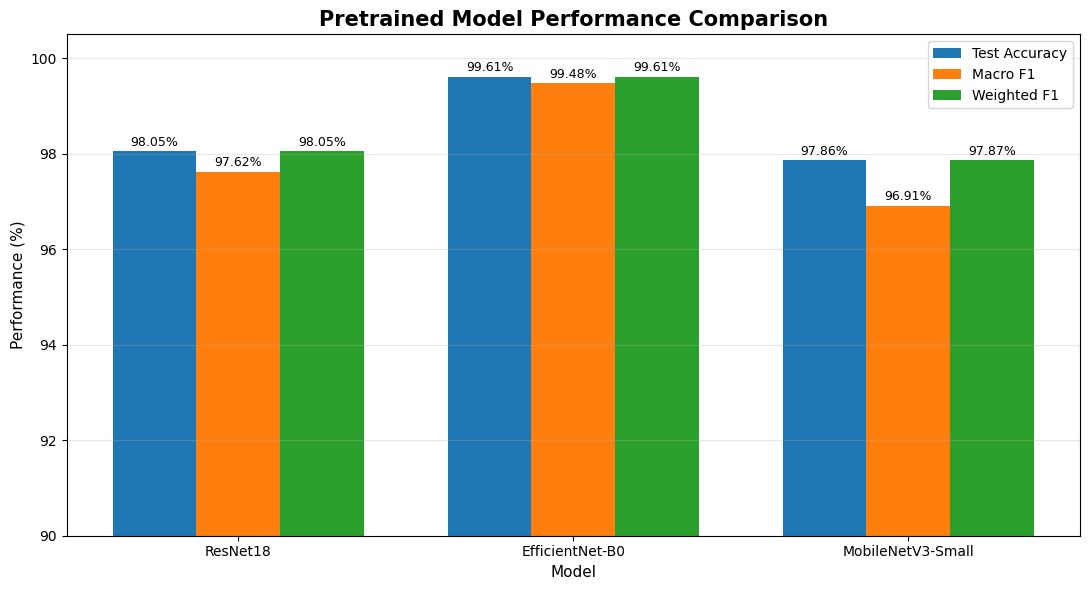

In [8]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================
# MODEL RESULTS
# ============================================

# Store the final test results from all
# three pretrained models.
model_names = [
    "ResNet18",
    "EfficientNet-B0",
    "MobileNetV3-Small"
]

test_accuracy = [
    0.9805,
    0.9961,
    0.9786
]

test_macro_f1 = [
    0.9762,
    0.9948,
    0.9691
]

test_weighted_f1 = [
    0.9805,
    0.9961,
    0.9787
]


# ============================================
# CONVERT TO PERCENTAGES
# ============================================

# Convert decimal scores to percentages
# for easier interpretation.
accuracy_percent = np.array(test_accuracy) * 100
macro_f1_percent = np.array(test_macro_f1) * 100
weighted_f1_percent = np.array(test_weighted_f1) * 100


# ============================================
# CREATE COMPARISON PLOT
# ============================================

x = np.arange(len(model_names))

width = 0.25

fig, ax = plt.subplots(
    figsize=(11, 6)
)

# Plot Test Accuracy.
bars1 = ax.bar(
    x - width,
    accuracy_percent,
    width,
    label="Test Accuracy"
)

# Plot Macro F1.
bars2 = ax.bar(
    x,
    macro_f1_percent,
    width,
    label="Macro F1"
)

# Plot Weighted F1.
bars3 = ax.bar(
    x + width,
    weighted_f1_percent,
    width,
    label="Weighted F1"
)


# ============================================
# ADD VALUE LABELS
# ============================================

# Add the exact percentage above each bar.
for bars in [bars1, bars2, bars3]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )


# ============================================
# FORMAT GRAPH
# ============================================

ax.set_title(
    "Pretrained Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel(
    "Performance (%)",
    fontsize=11
)

ax.set_xlabel(
    "Model",
    fontsize=11
)

ax.set_xticks(x)

ax.set_xticklabels(
    model_names
)

# Our scores are already very high, so start
# the axis at 90% to make differences visible.
ax.set_ylim(
    90,
    100.5
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()